In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("Manufacture Data Clean Final.csv", encoding="latin1")
df.head()

,Job,SerialNumber,StockCode,StockDescription,TestDate,UnitType,Tester name,PassFail,TesterEmpNumber,FaultDesc,...,FaultDesc4,FaultFixTime4,FaultDesc5,FaultFixTime5,FaultResolution,Comments,TotalFixTime,AssEmpName,AssDate,FixCost
0,JOB-000001,SERIAL-000001,STOCK-000057,PRODUCT-000057,04/10/2025,UNIT-000014,Tester F,F,106,Trapped Wires,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Trapped Wires identified during test; unit did...,90,Assembler H,06/10/2025,£76.50
1,JOB-000001,SERIAL-000002,STOCK-000051,PRODUCT-000051,14/10/2025,UNIT-000033,Tester L,F,112,Broken Wires,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Broken Wires identified during test; unit did ...,15,Assembler C,17/10/2025,£12.75
2,JOB-000001,SERIAL-000003,STOCK-000113,PRODUCT-000113,24/10/2025,UNIT-000066,Tester F,F,106,Incorrectly Wired,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Incorrectly Wired identified during test; unit...,20,Assembler J,25/10/2025,£17.00
3,JOB-000001,SERIAL-000004,STOCK-000119,PRODUCT-000119,03/10/2025,UNIT-000043,Tester L,F,112,Wires Not Fitted,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Wires Not Fitted identified during test; unit ...,25,Assembler E,05/10/2025,£21.25
4,JOB-000002,SERIAL-000005,STOCK-000066,PRODUCT-000066,13/10/2025,UNIT-000060,Tester F,F,106,Loose Wires,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Loose Wires identified during test; unit did n...,30,Assembler L,16/10/2025,£25.50


#Originally ran normal P chart then realised the mean was shifting as conditions improved - re ran whith three month stepped shift after this

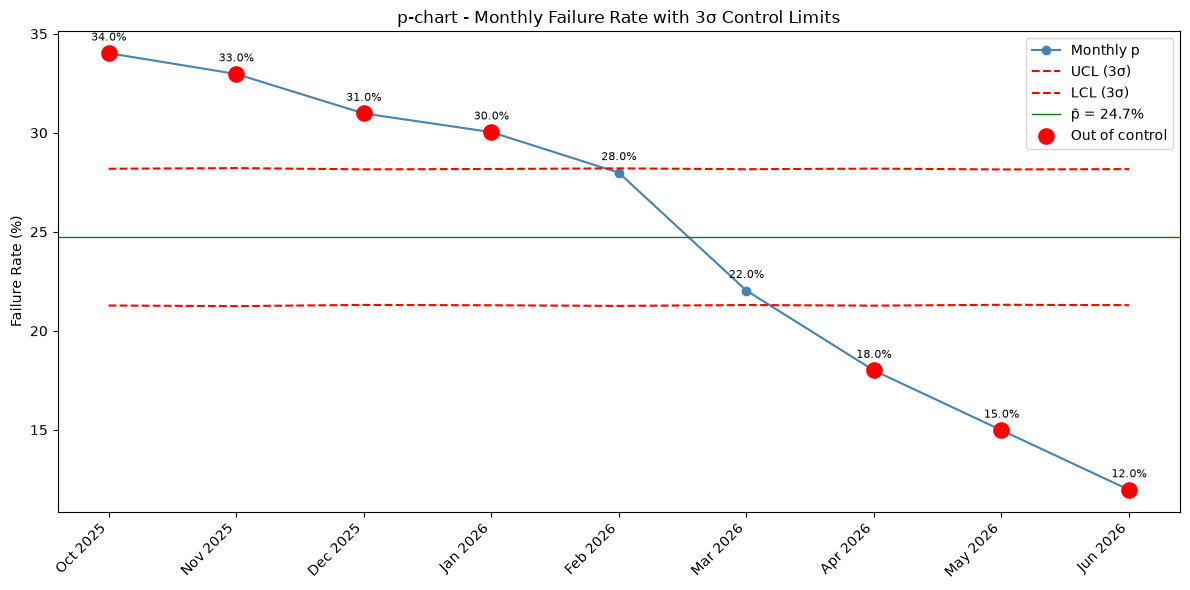

Overall failure rate p̄ = 24.73%
Out-of-control months:
              n  fails         p       UCL       LCL
TestMonth                                           
2025-10    1405    478  0.340214  0.281855  0.212791
2025-11    1380    455  0.329710  0.282166  0.212480
2025-12    1430    443  0.309790  0.281551  0.213094
2026-01    1415    425  0.300353  0.281732  0.212913
2026-04    1400    252  0.180000  0.281916  0.212729
2026-05    1435    215  0.149826  0.281492  0.213154
2026-06    1420    170  0.119718  0.281672  0.212974


In [14]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

monthly = df.groupby('TestMonth')['PassFail'].agg(
    n='count',
    fails=lambda s: (s == 'F').sum()
).sort_index()
monthly['p'] = monthly['fails'] / monthly['n']

# Centre line = overall failure rate; limits = p_bar +/- 3 * sqrt(p_bar(1-p_bar)/n_i)
p_bar = monthly['fails'].sum() / monthly['n'].sum()
sigma = np.sqrt(p_bar * (1 - p_bar) / monthly['n'])
monthly['UCL'] = np.clip(p_bar + 3 * sigma, 0, 1)
monthly['LCL'] = np.clip(p_bar - 3 * sigma, 0, 1)

labels = monthly.index.strftime('%b %Y')
ooc = (monthly['p'] > monthly['UCL']) | (monthly['p'] < monthly['LCL'])

plt.figure(figsize=(12, 6))
plt.plot(labels, monthly['p'] * 100, marker='o', color='steelblue', label='Monthly p')
plt.plot(labels, monthly['UCL'] * 100, color='red', linestyle='--', label='UCL (3σ)')
plt.plot(labels, monthly['LCL'] * 100, color='red', linestyle='--', label='LCL (3σ)')
plt.axhline(p_bar * 100, color='green', linestyle='-', linewidth=1,
            label=f'p̄ = {p_bar*100:.1f}%')

# Flag out-of-control points
plt.scatter(np.array(labels)[ooc.values], monthly['p'][ooc].values * 100,
            color='red', s=120, zorder=5, label='Out of control')

for x, y in zip(labels, monthly['p'] * 100):
    plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Failure Rate (%)")
plt.title("p-chart - Monthly Failure Rate with 3σ Control Limits")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"Overall failure rate p̄ = {p_bar*100:.2f}%")
print("Out-of-control months:")
print(monthly.loc[ooc, ['n', 'fails', 'p', 'UCL', 'LCL']])

#We would expect the rate of improvement to slow down- no such rapid drops in mean / St-Dev

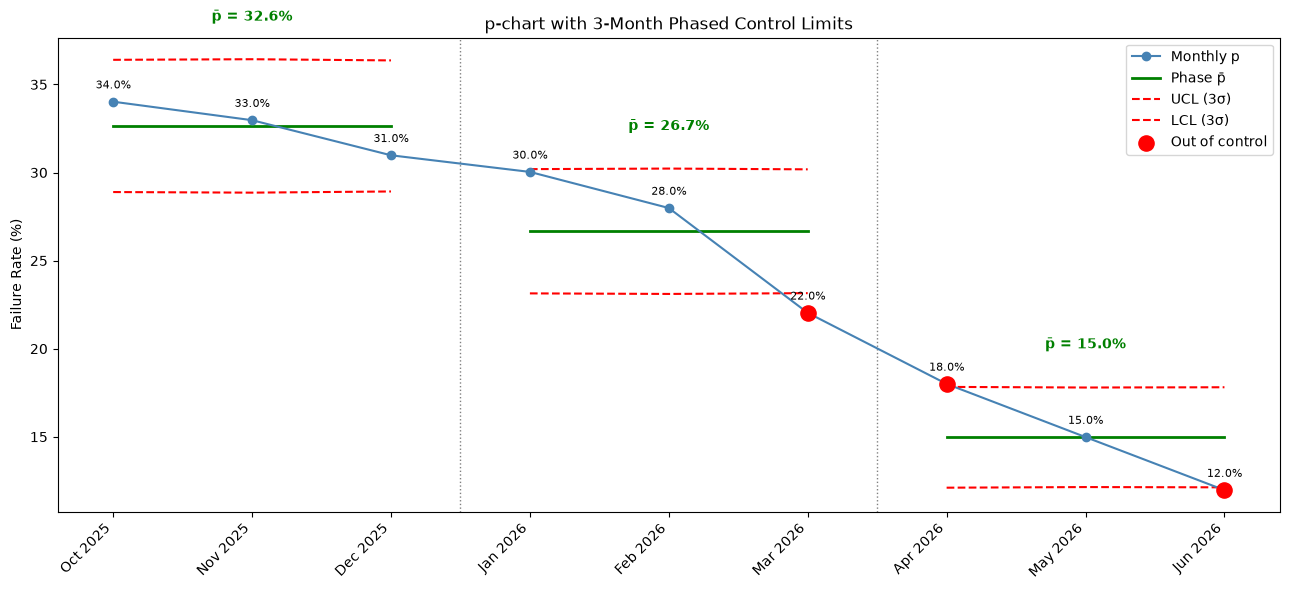

Phase summary:
         n_total  fails_total     p_bar  p_bar_pct
PhaseId                                           
0           4215         1376  0.326453      32.65
1           4230         1128  0.266667      26.67
2           4255          637  0.149706      14.97

Out-of-control months:
              n  fails         p     p_bar       UCL       LCL
TestMonth                                                     
2026-03    1425    314  0.220351  0.266667  0.301810  0.231523
2026-04    1400    252  0.180000  0.149706  0.178313  0.121100
2026-06    1420    170  0.119718  0.149706  0.178110  0.121302


In [12]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

monthly = df.groupby('TestMonth')['PassFail'].agg(
    n='count',
    fails=lambda s: (s == 'F').sum()
).sort_index()
monthly['p'] = monthly['fails'] / monthly['n']

# Assign each month to a 3-month phase
monthly['PhaseId'] = np.arange(len(monthly)) // 3

# Phase-level p_bar; per-month sigma uses its own n but the phase p_bar
phase_stats = monthly.groupby('PhaseId').agg(
    n_total=('n', 'sum'),
    fails_total=('fails', 'sum')
)
phase_stats['p_bar'] = phase_stats['fails_total'] / phase_stats['n_total']

monthly = monthly.join(phase_stats['p_bar'], on='PhaseId')
sigma = np.sqrt(monthly['p_bar'] * (1 - monthly['p_bar']) / monthly['n'])
monthly['UCL'] = np.clip(monthly['p_bar'] + 3 * sigma, 0, 1)
monthly['LCL'] = np.clip(monthly['p_bar'] - 3 * sigma, 0, 1)

labels = monthly.index.strftime('%b %Y')
ooc = (monthly['p'] > monthly['UCL']) | (monthly['p'] < monthly['LCL'])

plt.figure(figsize=(13, 6))

# Monthly p as a continuous line - the process
plt.plot(labels, monthly['p'] * 100, marker='o', color='steelblue', label='Monthly p', zorder=3)

# Step-function limits and centre line, one segment per phase
for pid, grp in monthly.groupby('PhaseId'):
    mask = (monthly['PhaseId'] == pid).values
    xs = np.array(labels)[mask]
    plt.plot(xs, grp['p_bar'] * 100, color='green', linewidth=2,
             label='Phase p̄' if pid == 0 else None)
    plt.plot(xs, grp['UCL'] * 100, color='red', linestyle='--',
             label='UCL (3σ)' if pid == 0 else None)
    plt.plot(xs, grp['LCL'] * 100, color='red', linestyle='--',
             label='LCL (3σ)' if pid == 0 else None)

# Vertical separators between phases
boundaries = np.where(np.diff(monthly['PhaseId'].values) != 0)[0]
for b in boundaries:
    plt.axvline(b + 0.5, color='gray', linestyle=':', linewidth=1)

# Flag out-of-control points
plt.scatter(np.array(labels)[ooc.values], monthly['p'][ooc].values * 100,
            color='red', s=120, zorder=5, label='Out of control')

# Annotate phase p̄ above each segment
for pid, grp in monthly.groupby('PhaseId'):
    mask = (monthly['PhaseId'] == pid).values
    mid_x = np.array(labels)[mask][len(grp) // 2]
    plt.text(mid_x, grp['UCL'].max() * 100 + 2,
             f"p̄ = {grp['p_bar'].iloc[0]*100:.1f}%",
             ha='center', va='bottom', color='green', fontsize=10, fontweight='bold')

# Value labels on the monthly points
for x, y in zip(labels, monthly['p'] * 100):
    plt.text(x, y + 0.6, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Failure Rate (%)")
plt.title("p-chart with 3-Month Phased Control Limits")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Phase summary:")
print(phase_stats.assign(p_bar_pct=lambda d: (d['p_bar']*100).round(2)))
print("\nOut-of-control months:")
print(monthly.loc[ooc, ['n', 'fails', 'p', 'p_bar', 'UCL', 'LCL']])

#Paretto chart completed to show wiring issues with all 5 seperate faults as 1 - clearly shows wiring and gas escapes the two main improvement areas

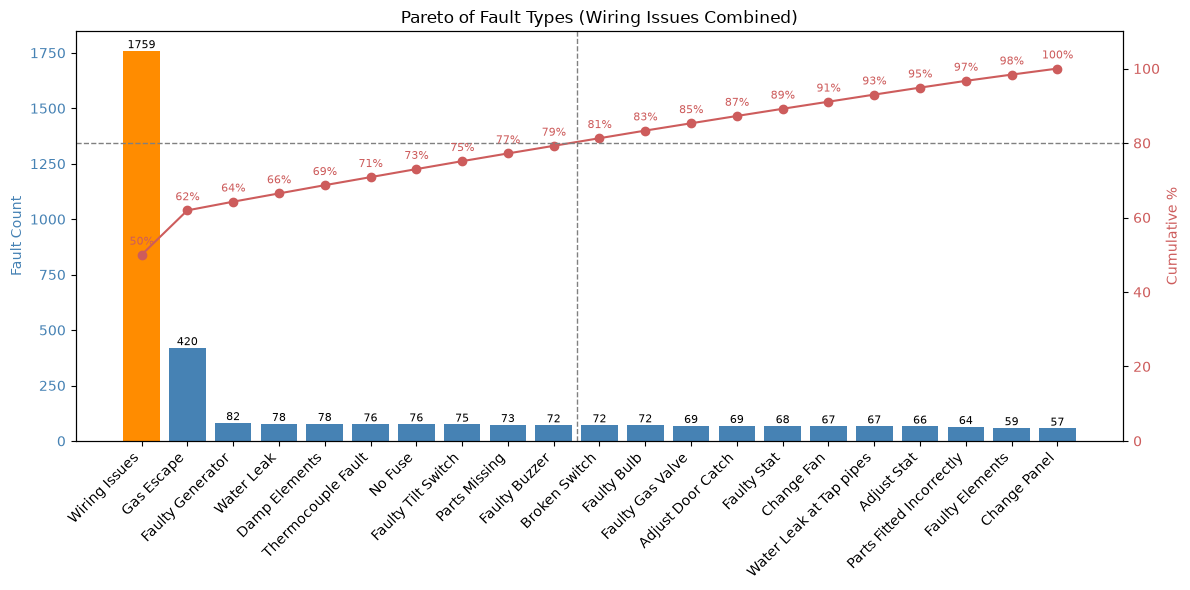

Vital few (10 faults driving ~80% of failures):
 - Wiring Issues
 - Gas Escape
 - Faulty Generator
 - Water Leak
 - Damp Elements
 - Thermocouple Fault
 - No Fuse
 - Faulty Tilt Switch
 - Parts Missing
 - Faulty Buzzer


In [13]:


fault_cols = ['FaultDesc', 'FaultDesc2', 'FaultDesc3', 'FaultDesc4', 'FaultDesc5']
wire_faults = ['Loose Wires', 'Trapped Wires', 'Wires Not Fitted',
               'Broken Wires', 'Incorrectly Wired']

faults = df[fault_cols].stack().dropna()
# Roll the 5 wiring modes into a single category
faults = faults.where(~faults.isin(wire_faults), 'Wiring Issues')

fault_counts = faults.value_counts()
cum_pct = fault_counts.cumsum() / fault_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Colour the combined wiring bar differently so it reads at a glance
colors = ['darkorange' if f == 'Wiring Issues' else 'steelblue'
          for f in fault_counts.index]
bars = ax1.bar(fault_counts.index, fault_counts.values, color=colors)
ax1.set_ylabel("Fault Count", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(range(len(fault_counts.index)))
ax1.set_xticklabels(fault_counts.index, rotation=45, ha='right')

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
             ha='center', va='bottom', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(fault_counts.index, cum_pct.values, color='indianred', marker='o')
ax2.set_ylabel("Cumulative %", color='indianred')
ax2.tick_params(axis='y', labelcolor='indianred')
ax2.set_ylim(0, 110)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)

cutoff_idx = int((cum_pct <= 80).sum())
ax2.axvline(cutoff_idx - 0.5, color='gray', linestyle='--', linewidth=1)

for x, y in zip(fault_counts.index, cum_pct.values):
    ax2.text(x, y + 2, f'{y:.0f}%', ha='center', va='bottom',
             color='indianred', fontsize=8)

plt.title("Pareto of Fault Types (Wiring Issues Combined)")
plt.tight_layout()
plt.show()

vital_few = fault_counts.index[:cutoff_idx].tolist()
print(f"Vital few ({cutoff_idx} faults driving ~80% of failures):")
for f in vital_few:
    print(" -", f)